# Reinforcement Learning Programming Assignment

## MinAtar: Learning to Play Atari-Style Games

This assignment asks you to design, implement, and analyze reinforcement learning algorithms on MinAtar, a set of simplified Atari-style environments. MinAtar provides the visual complexity of Atari games at reduced computational cost: observations are 10×10 pixel grids with a small number of channels, and episodes run faster than their full-scale counterparts.

You will work primarily with **Breakout**, then test whether your methods transfer to other MinAtar games.

### Objectives

By the end of this assignment, you should be able to:

- Analyze an RL environment: state space, action space, reward structure, and episode dynamics
- Select and justify appropriate state representations for learning
- Implement at least two RL algorithms: one classical, one using neural networks
- Interpret learned policies through visualization and quantitative analysis
- Diagnose training issues and apply techniques to address them
- Evaluate generalization across different environments

### Deliverables

Submit a single Jupyter notebook that serves as both your implementation and your report. Your notebook should:

1. **Run end-to-end** without errors
2. **Document your approach** with clear explanations in markdown cells
3. **Present results** with well-labeled figures and tables
4. **Analyze findings** with interpretation of what works, what fails, and why

### Rules

- **Implement RL algorithms yourself.** Do not use RL libraries (stable-baselines, RLlib, CleanRL, etc.)
- **Standard libraries are allowed.** PyTorch, NumPy, scikit-learn, matplotlib, and similar tools are permitted.
- **Cite your sources.** If you adapt an algorithm from a paper or other resource, reference it.

---
## Part 0: Environment and Baselines

The code below sets up the MinAtar Breakout environment and provides two baseline policies for comparison:

- **Random policy**: selects actions uniformly at random
- **Heuristic policy**: moves the paddle toward the ball's horizontal position


In [1]:
%pip install numpy gymnasium minatar torch tqdm


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import torch
import gymnasium as gym
from minatar import Environment
from minatar.gym import register_envs

SEED = 43
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

if "MinAtar/Breakout-v1" not in gym.envs.registry:
    register_envs()

In [3]:
def random_policy(observation, num_actions):
    return np.random.randint(num_actions)

In [4]:
def breakout_heuristic_policy(observation, num_actions):
    paddle_channel = observation[:, :, 0]
    ball_channel = observation[:, :, 1]

    paddle_pos = np.where(paddle_channel == 1)
    ball_pos = np.where(ball_channel == 1)

    if len(paddle_pos[1]) == 0 or len(ball_pos[1]) == 0:
        return 0

    paddle_x = paddle_pos[1].mean()
    ball_x = ball_pos[1].mean()

    if ball_x < paddle_x:
        return 1
    elif ball_x > paddle_x:
        return 2
    else:
        return 0

In [5]:
def run_episode(env, policy_fn):
    """
    Runs a single episode using the provided policy function.
    Returns the total reward and the number of steps taken.

    Parameters
    ----------
    env : gymnasium.Env
        The environment to run the episode in.
    policy_fn : function
        A function that takes an observation and the number of actions, and returns an action.
    
    Returns
    -------
    total_reward : float
        The total reward accumulated during the episode.
    steps : int
        The number of steps taken in the episode.
    """
    observation, info = env.reset()
    num_actions = env.action_space.n

    total_reward = 0
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated):
        action = policy_fn(observation, num_actions)
        observation, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1

    return total_reward, steps


def evaluate_policy(env, policy_fn, num_episodes=100):
    """
    Evaluates a policy by running it in the environment for a specified number of episodes.

    Parameters
    ----------
    env : gymnasium.Env
        The environment to run the episodes in.
    policy_fn : function
        A function that takes an observation and the number of actions, and returns an action.
    num_episodes : int, optional
        The number of episodes to run (default is 100).

    Returns
    -------
    rewards : np.ndarray
        An array of total rewards for each episode.
    steps_list : np.ndarray
        An array of the number of steps taken in each episode.
    """
    rewards = []
    steps_list = []

    for _ in range(num_episodes):
        total_reward, steps = run_episode(env, policy_fn)
        rewards.append(total_reward)
        steps_list.append(steps)

    return np.array(rewards), np.array(steps_list)

In [6]:
env = gym.make("MinAtar/Breakout-v1")
env.reset()

print(f"Observation shape: {env.observation_space.shape}")
print(f"Number of actions: {env.action_space.n}")

Observation shape: (10, 10, 4)
Number of actions: 3


In [7]:
num_episodes = 100

random_rewards, random_steps = evaluate_policy(env, random_policy, num_episodes)
print(f"Random Policy:")
print(f"  Reward: {random_rewards.mean():.2f} +/- {random_rewards.std():.2f}")
print(f"  Steps:  {random_steps.mean():.2f} +/- {random_steps.std():.2f}")

heuristic_rewards, heuristic_steps = evaluate_policy(env, breakout_heuristic_policy, num_episodes)
print(f"\nHeuristic Policy:")
print(f"  Reward: {heuristic_rewards.mean():.2f} +/- {heuristic_rewards.std():.2f}")
print(f"  Steps:  {heuristic_steps.mean():.2f} +/- {heuristic_steps.std():.2f}")

Random Policy:
  Reward: 0.33 +/- 0.63
  Steps:  9.34 +/- 6.47

Heuristic Policy:
  Reward: 7.84 +/- 7.92
  Steps:  91.94 +/- 91.18


In [8]:
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

observations = []
rewards = []

def render_frame(env):
    frame = env.render()
    return (frame * 255).astype(np.uint8)


def run_episode_with_frames(env, policy_fn, max_steps=500):
    observation, info = env.reset()
    num_actions = env.action_space.n
    frames = [render_frame(env)]

    total_reward = 0
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        action = policy_fn(observation, num_actions)
        observation, reward, terminated, truncated, info = env.step(action)
        observations.append(observation)
        rewards.append(reward)
        frames.append(render_frame(env))
        total_reward += reward
        steps += 1

    return frames, total_reward, steps


def animate_episode(frames, interval=50):
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.axis("off")
    img = ax.imshow(frames[0], interpolation="nearest")

    def update(frame):
        img.set_array(frame)
        return [img]

    anim = animation.FuncAnimation(
        fig, update, frames=frames, interval=interval, blit=True
    )
    plt.close(fig)
    return anim


env_visual = gym.make("MinAtar/Breakout-v1", render_mode="rgb_array", disable_env_checker=True)
env_visual.reset()

frames, reward, steps = run_episode_with_frames(env_visual, breakout_heuristic_policy)
print(f"Episode: Reward = {reward}, Steps = {steps}")

anim = animate_episode(frames, interval=100)
HTML(anim.to_jshtml())

Episode: Reward = 14, Steps = 154


---

## Part 1: Environment Analysis [5 marks]

Before designing learning algorithms, you must understand the environment.

### Questions to Address

1. **State space**: What is the shape of the observations? What does each channel represent? How many unique states are theoretically possible?

2. **Action space**: What actions are available? How do they affect the game state?

3. **Reward structure**: When and how frequently does the agent receive rewards? What is the typical range of episode returns?

4. **Episode dynamics**: What causes an episode to terminate? What is the distribution of episode lengths under the random and heuristic policies?

5. **Stochasticity**: Is the environment deterministic or stochastic? If stochastic, what are the sources of randomness?

Visualize observations, reward distributions, and episode statistics to support your analysis.

### _Answers_
1.

In [9]:
def render_observation(observation: torch.Tensor):
    for channel in range(observation.shape[2]):
        X = np.where(observation[:,:,channel]==1)[1]
        Y = np.where(observation[:,:,channel]==1)[0]
        coords = np.stack((X, Y), axis=-1)
        plt.scatter(X, Y, label=f"Channel {channel}")
        if channel == observation.shape[2] - 1:
            plt.legend(title="Channels")
    plt.xlim(0,9)
    plt.ylim(0,9)
    plt.gca().invert_yaxis()
    plt.grid()
    plt.show()

Observation shape: (10, 10, 4)


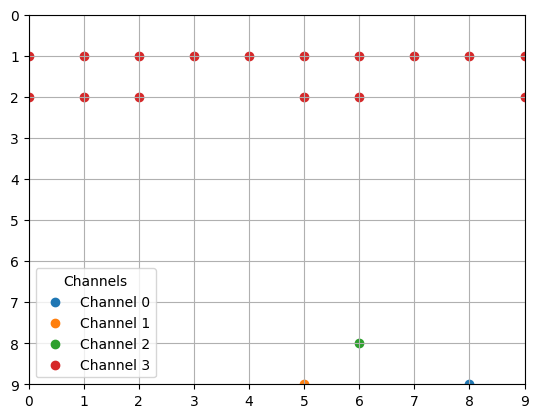

In [10]:
obs = observations[-1]
print(f"Observation shape: {obs.shape}")
render_observation(obs)


**Answer**: As demonstrated by the code above, observations have shape $(10,10,4)$:
- 1st dimension: Y coordinate, top to bottom
- 2nd dimension: X coordinate, left to right
- 3rd dimension: 0 for paddle, 1 for ball's head, 2 for ball's tail, 3 for bricks

When ignoring the constraints such as restricted positions, no intersection, ball's continuity, etc, we have  $$|\mathcal{X}|=10*10*4=400$$
2. There is 3 actions available:
- $a=0$: do nothing
- $a=1$: go right $\Rightarrow$ paddle's x coordinate incremented of 1 if possible
- $a=2$: go left $\Rightarrow$ paddle's x coordinate decremented of 1 if possible
3.

In [11]:
steps_with_reward = np.where(np.array(rewards) == 1)[0]
print(f"Steps with reward = 1: {steps_with_reward}")
avg_reward_per_step = np.sum(rewards) / (np.arange(len(rewards)) + 1)
print(f"Average reward per step: {avg_reward_per_step[-1]:.4f}")
gap_between_rewards = np.diff(steps_with_reward)
print(f"Steps between rewards: mean: {gap_between_rewards.mean():.2f}, min: {gap_between_rewards.min()}, max: {gap_between_rewards.max()}")

print(f"Heuristic reward: {heuristic_rewards.mean():.2f} +/- {heuristic_rewards.std():.2f}")

Steps with reward = 1: [ 10  20  31  42  52  63  74  84  95 106 116 127 138 148]
Average reward per step: 0.0909
Steps between rewards: mean: 10.62, min: 10, max: 11
Heuristic reward: 7.84 +/- 7.92


**Answer**: Agent receives reward $1$ every time a brick breaks. It receives one about every $10.67$ steps, 10 to 13 depending on how far the ball went through the brick layers.

When playing the heuristic, the agent's typical return is $10.16 \pm 10.12$.

4. What causes an episode to end is either
- ball falls to the ground _i.e._ ball's head y-coordinate is 9 _i.e._ ```observation[8, :, 1].any() is True```
- all bricks are broken _i.e._ ```observation[:, :, 3].any() is False```

5. The environment is deterministic: the ball always bounces the same way. The only source of randomness is initial state of ball and paddle but it's not considered part of the environment.

---

## Part 2: A Classical RL Method [8 marks]

Implement a reinforcement learning algorithm that does not use neural networks for function approximation.

### Requirements

- Choose an appropriate algorithm given your analysis of the state space
- Choose an appropriate state representation
- Justify your choices based on the environment properties you identified in Part 1

### Questions to Address

1. **State representation**: How do you represent the state? Why is this representation appropriate for your chosen algorithm?

2. **Algorithm description**: What algorithm did you implement? Write out the update rules.

3. **Hyperparameters**: What hyperparameters does your method have? How did you select their values?

4. **Learning curves**: Plot the return during training. Include error bars or confidence intervals if you run multiple seeds.

5. **Comparison to baselines**: How does your trained policy compare to the random and heuristic baselines?

### Answers

#### Analysis
Even though the model is known, the state space's dimension is way too large for a planning algorithm: it would be a $O(3*400^2)$ time complexity.

Then one needs to choose a learning algorithm such as fitted Q-iteration. The state space has no clear better representation than _linear_:
$$Q_\theta \in \{\theta^T\phi(x,a)\}$$

1. $\phi$ is a custom feature that encodes the following information as one-hot:
- paddle's x coordinate only (its $y$ is always 9)
- bricks $(x,y)$ coordinatees where $y \in [1, 3]$
- ball tail's relative position to the head: 0=top, 1=topright, ..., 7=topleft
- ball head's coordinates
2. The implemented algorithm is fitted Q-iteration:

In [12]:
from collections import deque
import random
from tqdm.notebook import trange
from abc import ABC, abstractmethod
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from typing import Callable

dtype = torch.float64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [13]:
def evaluate(env_name: str, policy_fn, n_episodes: int = 10, seed: int = 0) -> float:
    """Evaluate a policy for n_episodes, return mean return."""
    env = gym.make(env_name)
    total_returns = []

    for i in range(n_episodes):
        state, _ = env.reset(seed=seed + i)
        ep_return = 0.0
        done = False

        while not done:
            action = policy_fn(state)
            state, reward, terminated, truncated, _ = env.step(action)
            ep_return += reward
            done = terminated or truncated

        total_returns.append(ep_return)

    env.close()
    return float(np.mean(total_returns))

In [14]:
TAIL_POS_ENCODING = torch.tensor(
    [[7,0,1],
     [6,8,2],
     [5,4,3]],
    device=device,
    dtype=torch.long
)

def phi_minatar(observation: torch.Tensor, actions: torch.Tensor) -> torch.Tensor:
    """
        State-space representation function returning a custom one-hot encoding of (x,a).
        Inputs can be either batched or not. If only one of them is batched, the other will be automatically expanded to match the batch size.

        Parameters
        ----------
        observation : torch.Tensor
            The observation from the environment, expected to be a 3D tensor with shape (height, width, channels) or (batch_size, height, width, channels).
        actions : torch.Tensor
            The list of actions on which we want to evaluate, expected to be a 1D tensor with shape (num_actions,) or (batch_size, num_actions). 

        Returns
        ----------
        res : torch.Tensor
            A tensor where each row corresponds to the feature vector for a given action, with shape (num_actions, feature_dim) or (batch_size, num_actions, feature_dim).

    """
    actions_batched = actions.ndim == 2
    observation_batched = observation.ndim == 4
    batched = actions_batched or observation_batched
    if batched:
        if observation_batched and not actions_batched:
            actions = actions.unsqueeze(0).expand(observation.shape[0], -1)
        elif actions_batched and not observation_batched:
            observation = observation.unsqueeze(0).expand(actions.shape[0], -1, -1, -1)
        else: # Case when both are batched
            assert actions.shape[0] == observation.shape[0], f"Batch sizes should be the same, got {actions.shape[0]} for actions and {observation.shape[0]} for observation."
    else:
        actions = actions.unsqueeze(0)
        observation = observation.unsqueeze(0)
    
    batch_size = observation.shape[0]
    observation = observation.float()

    head_flat = observation[..., 1].reshape(batch_size, -1).argmax(dim=1)
    tail_flat = observation[..., 2].reshape(batch_size, -1).argmax(dim=1)

    head_y, head_x = head_flat // 10, head_flat % 10
    tail_y, tail_x = tail_flat // 10, tail_flat % 10

    deltay = (tail_y - head_y + 1)
    deltax = (tail_x - head_x + 1)
    tail_idx = TAIL_POS_ENCODING[deltay, deltax]
    tail_onehot = F.one_hot(tail_idx.long(), num_classes=9).float()

    head_pos_x_onehot = F.one_hot(head_x, num_classes=10).float()
    head_pos_y_onehot = F.one_hot(head_y, num_classes=10).float()

    # FIX: use x-index from nonzero(...), not batch index
    paddle_x = torch.argmax(observation[:, 9, :, 0], dim=1)
    paddle_x_onehot = F.one_hot(paddle_x, num_classes=10).float()

    bricks_pos_onehot = observation[:,1:4,:,3].flatten(start_dim=1).float()

    action_onehot = F.one_hot(actions.long(), num_classes=3).float()

    obs_onehot = torch.cat(
        [
            bricks_pos_onehot,
            paddle_x_onehot,
            tail_onehot,
            head_pos_x_onehot,
            head_pos_y_onehot,
        ],
        dim=1,
    )

    res = torch.cat(
        [
            obs_onehot.unsqueeze(1).expand(-1, action_onehot.shape[1], -1),
            action_onehot.float(),
        ],
        dim=-1
    )

    if not batched:
        res = res.squeeze(0)

    return res
    


Example

/tmp/ipykernel_6356/2191873883.py:1: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  obs = torch.tensor(observations[:3], device=device)
/tmp/ipykernel_6356/2191873883.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  obs = torch.tensor(observations[:3], device=device)


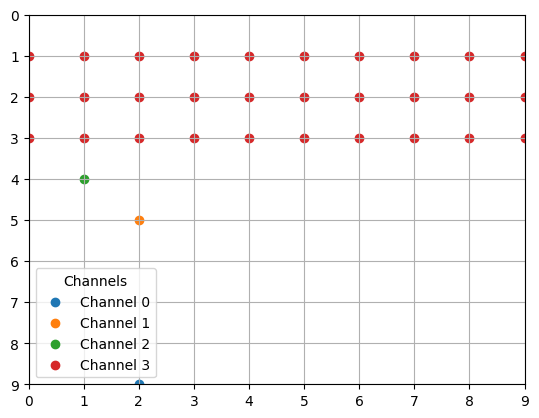

Bricks presence: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0')
Paddle x index: tensor([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0')
Tail relative position: tensor([0., 0., 0., 0., 0., 0., 0., 1., 0.], device='cuda:0')
Head x position: tensor([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0')
Head y position: tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.], device='cuda:0')
Action one-hot: tensor([1., 0., 0.], device='cuda:0')


In [15]:
obs = torch.tensor(observations[:3], device=device)
example_obs = obs[1]
render_observation(example_obs.cpu().numpy())
actions = torch.tensor([0, 1, 2], device=device)
phi_example = phi_minatar(obs, actions)[1,0]
print("Bricks presence:", phi_example[:30])
print("Paddle x index:", phi_example[30:40])
print("Tail relative position:", phi_example[40:49])
print("Head x position:", phi_example[49:59])
print("Head y position:", phi_example[59:69])
print("Action one-hot:", phi_example[69:72])

In [16]:
class ReplayBuffer:
    """Fixed-size ring buffer storing (s, a, r, s', done) transitions."""

    def __init__(self, capacity: int, pin_memory: bool = True):
        self.capacity = capacity
        self.pin_memory = pin_memory
        self.ptr = 0
        self.size = 0

        self.states = None
        self.next_states = None
        self.actions = None
        self.rewards = None
        self.dones = None

    def _init_storage(self, state_shape: tuple[int, ...]) -> None:
        self.states = torch.empty((self.capacity, *state_shape), dtype=torch.uint8, pin_memory=self.pin_memory)
        self.next_states = torch.empty((self.capacity, *state_shape), dtype=torch.uint8, pin_memory=self.pin_memory)
        self.actions = torch.empty((self.capacity,), dtype=torch.long, pin_memory=self.pin_memory)
        self.rewards = torch.empty((self.capacity,), dtype=torch.float32, pin_memory=self.pin_memory)
        self.dones = torch.empty((self.capacity,), dtype=torch.float32, pin_memory=self.pin_memory)

    def push(self, state, action: int, reward: float, next_state, done: bool):
        state_t = torch.as_tensor(state, device="cpu")
        next_state_t = torch.as_tensor(next_state, device="cpu")

        if self.states is None:
            self._init_storage(tuple(state_t.shape))

        self.states[self.ptr].copy_(state_t.to(dtype=torch.uint8))
        self.next_states[self.ptr].copy_(next_state_t.to(dtype=torch.uint8))
        self.actions[self.ptr] = int(action)
        self.rewards[self.ptr] = float(reward)
        self.dones[self.ptr] = float(done)

        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def __len__(self) -> int:
        return self.size

    def sample(self, batch_size: int):
        """Sample a random mini-batch of transitions."""
        idx = torch.randint(0, self.size, (batch_size,), device="cpu")

        states = self.states[idx].to(device=device, dtype=torch.float32, non_blocking=True)
        actions = self.actions[idx].to(device=device, non_blocking=True)
        rewards = self.rewards[idx].to(device=device, non_blocking=True)
        next_states = self.next_states[idx].to(device=device, dtype=torch.float32, non_blocking=True)
        dones = self.dones[idx].to(device=device, non_blocking=True)

        return states, actions, rewards, next_states, dones

In [17]:
class Agent(ABC):
    """Base class for all RL agents."""

    @abstractmethod
    def act(self, state: np.ndarray, explore: bool = True):
        """Select an action given the current state."""
        ...

    @abstractmethod
    def update(self, **kwargs):
        """Update internal estimates from experience."""
        ...

In [18]:
class FQIAgent(Agent):
    def __init__(
        self,
        state_dim: int,
        action_dim: int,
        feature_dim: int,
        phi: Callable[[torch.Tensor, torch.Tensor], torch.Tensor],
        lr: float = 1e-3,
        gamma: float = 0.99,
        buffer_size: int = 10_000,
        batch_size: int = 64,
        target_update_freq: int = 200, # Frequency (in steps) to update the target network
        epsilon_start: float = 1.0,
        epsilon_end: float = 0.01,
        epsilon_decay_steps: int = 5000,
    ):
        """
        Initializes the FQI agent with the given hyperparameters.

        Parameters
        ----------
        state_dim : int
            Dimension of the state space (e.g., 4 for CartPole-v1).
        action_dim : int
            Dimension of the action space (e.g., 2 for CartPole-v1).
        feature_dim : int
            Dimension of the feature space returned by the representation function phi.
        lr : float, optional
            Learning rate for the Adam optimizer.
        gamma : float, optional
            Discount factor for future rewards.
        phi : Callable[[torch.Tensor, torch.Tensor], torch.Tensor]
            State-space representation function that takes an observation and a set of actions, and returns a feature matrix.
        buffer_size : int, optional
            Maximum capacity of the replay buffer.
        batch_size : int, optional
            Size of the mini-batch sampled from the replay buffer.
        epsilon_start : float, optional
            Initial exploration rate.
        epsilon_end : float, optional
            Minimum exploration rate.
        epsilon_decay_steps : int, optional
            Number of steps over which epsilon decays.
        """
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq

        # Linear model and representation function
        self.phi = phi
        self.q_linear = nn.Linear(feature_dim, 1, bias=True, device=device)
        self.target_linear = nn.Linear(feature_dim, 1, bias=True, device=device)
        self.target_linear.load_state_dict(self.q_linear.state_dict())

        self.optimizer = torch.optim.Adam(self.q_linear.parameters(), lr=lr)
        self.buffer = ReplayBuffer(buffer_size)

        # Epsilon schedule
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = (epsilon_start - epsilon_end) / epsilon_decay_steps
        self.step_count = 0

    # GPI Improvement step: epsilon greedy action selection
    @torch.no_grad()
    def act(self, state: np.ndarray, explore: bool = True) -> int:
        """Epsilon-greedy action selection."""
        # With probability epsilon, take random action
        if explore and random.random() < self.epsilon:
            return random.randrange(self.action_dim)

        # Otherwise, take greedy action
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        actions_return = self.q_linear(self.phi(state_t, torch.arange(self.action_dim, device=device)))
        return int(actions_return.argmax(dim=1).item())

    # GPI Evaluation stept: Q-function update via gradient descent
    def update(self, **kwargs) -> float | None:
        """One gradient step on the Double-DQN loss."""
        if len(self.buffer) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)

        # Q(s, a) for the actions actually taken
        q_values = self.q_linear(self.phi(states, actions.unsqueeze(-1))).squeeze()

        with torch.no_grad():
            # best_actions = self.q_net(next_states).argmax(dim=1, keepdim=True)
            # next_q = self.target_net(next_states).gather(1, best_actions).squeeze(1)
            # targets = rewards + self.gamma * next_q * (1 - dones)

            # all_actions = torch.arange(self.action_dim, device=device).unsqueeze(0).expand(self.batch_size, -1)
            # q_next_all = self.linear(self.phi(next_states, all_actions)).squeeze(-1)
            # next_q = q_next_all.max(dim=1).values
            # targets = rewards + self.gamma * next_q * (1 - dones)   

            all_actions = torch.arange(self.action_dim, device=device).unsqueeze(0).expand(self.batch_size, -1)
            best_actions = self.q_linear(self.phi(next_states, all_actions)).argmax(dim=1, keepdim=True)
            next_q = self.target_linear(self.phi(next_states, all_actions)).gather(1, best_actions).squeeze()
            targets = rewards + self.gamma * next_q * (1 - dones)   

        loss = F.mse_loss(q_values, targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Decay epsilon and update target network
        self.epsilon = max(self.epsilon_end, self.epsilon - self.epsilon_decay)
        self.step_count += 1
        if self.step_count % self.target_update_freq == 0:
            self.target_linear.load_state_dict(self.q_linear.state_dict())

        return loss.item()

In [65]:
def train_FQI(
    agent: FQIAgent,
    env_name: str,
    n_episodes: int = 300,
    seed: int = 42,
    eval_every: int = 20,
    desc: str = "Training",
    store_action=None,
) -> list[float]:
    """Training loop for Fitted Q-Iteration"""
    env = gym.make(env_name)
    episode_returns: list[float] = []

    pbar = trange(n_episodes, desc=desc)
    for ep in pbar:
        state, _ = env.reset(seed=seed + ep)
        ep_return = 0.0
        done = False

        # === EPISODE LOOP ===
        # Each iteration: act -> step -> store -> sample -> update
        while not done:
            # 1. ACT: Select action using current policy (with exploration)
            action = agent.act(state)

            # 2. STEP: Execute action in environment
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # 3. STORE: Save transition to replay buffer
            if store_action is not None:
                store_action(agent, state, action, reward, next_state, done)
            else:
                agent.buffer.push(state, action, reward, next_state, float(done))

            # 4. UPDATE: Sample a random batch and perform gradient step
            agent.update()
            state = next_state
            ep_return += reward

        episode_returns.append(ep_return)

        if ep % eval_every == 0:
            eval_score = evaluate(env_name, lambda s: agent.act(s, explore=False))
            postfix = {"ret": f"{ep_return:.0f}", "eval": f"{eval_score:.0f}"}
            if hasattr(agent, "epsilon"):
                postfix["eps"] = f"{agent.epsilon:.2f}"
            pbar.set_postfix(**postfix)

    env.close()
    return episode_returns

In [19]:
def set_seed(seed: int = 42) -> None:
    """Fix random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

In [67]:
# SEEDS = [1, 2, 3]
SEEDS = [2]
dqn_runs = []
s = 1
for s in SEEDS:
    set_seed(s)
    env = gym.make("MinAtar/Breakout-v1")
    agent = FQIAgent(
        state_dim=env.observation_space.shape[0],
        action_dim=env.action_space.n,
        feature_dim=72,
        phi=phi_minatar
        )
    env.close()
    dqn_runs.append(
        train_FQI(agent, "MinAtar/Breakout-v1", n_episodes=500, seed=s, desc=f"DQN seed={s}")
    )

fqi_agent = agent  # keep last for video

DQN seed=2:   0%|          | 0/500 [00:00<?, ?it/s]

In [20]:
def record_video(env_name: str, policy_fn, max_steps: int = 500, seed: int = 0):
    """Record a single episode and return an HTML5 video."""
    from matplotlib import animation
    from IPython.display import HTML

    env = gym.make(env_name, render_mode="rgb_array")
    state, _ = env.reset(seed=seed)
    frames = [env.render()]
    done = False
    step = 0

    while not done and step < max_steps:
        action = policy_fn(state)
        state, _, terminated, truncated, _ = env.step(action)
        frames.append(env.render())
        done = terminated or truncated
        step += 1
    env.close()

    fig, ax = plt.subplots(figsize=(4, 3))
    ax.axis("off")
    img = ax.imshow(frames[0])
    def update(f):
        img.set_data(f)
        return [img]
    anim = animation.FuncAnimation(fig, update, frames=frames, interval=50, blit=True)
    plt.close(fig)
    return HTML(anim.to_jshtml())

In [ ]:
evaluate("MinAtar/Breakout-v1", lambda s: agent.act(s, explore=False))

0.4

In [ ]:
record_video("MinAtar/Breakout-v1", lambda s: fqi_agent.act(s, explore=False), seed=SEEDS[0])

/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:334: UserWarning: WARN: No render fps was declared in the environment (env.metadata['render_fps'] is None or not defined), rendering may occur at inconsistent fps.
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:275: UserWarning: WARN: RGB-array rendering should return a numpy array with dtype uint8, got float64
  logger.warn(


---

## Part 3: A Deep RL Method [10 marks]

Implement a reinforcement learning algorithm that uses neural networks for function approximation.

### Requirements

- Choose an appropriate algorithm
- Design a neural network architecture suited to the observation space
- Apply techniques to stabilize training as needed

### Questions to Address

1. **State representation**: Do you use the raw observation or a transformed representation? How does this choice influence your network architecture?

2. **Algorithm description**: What algorithm did you implement? Describe the loss function and update procedure.

3. **Architecture**: What neural network architecture did you use? Justify your design choices.

4. **Learning curves**: Plot training progress. Compare different hyperparameter choices, if applicable.

5. **Comparison**: How does the deep RL method compare to your classical RL method from Part 2? Consider sample efficiency, final performance, and training stability.

In [21]:
from torch.optim.lr_scheduler import MultiStepLR
import copy

class DQNAgent(Agent):
    def __init__(
        self,
        action_dim: int,
        net: nn.Module,
        phi: Callable[[torch.Tensor, torch.Tensor], torch.Tensor],
        lr: float = 1e-3,
        lr_milestones: list[int] = [],
        gamma: float = 0.99,
        buffer_size: int = 10_000,
        batch_size: int = 64,
        target_update_freq: int = 200, # Frequency (in steps) to update the target network
        epsilon_start: float = 1.0,
        epsilon_end: float = 0.01,
        epsilon_decay_steps: int = 5000,
    ):
        """
        Initializes the FQI agent with the given hyperparameters.

        Parameters
        ----------
        state_dim : int
            Dimension of the state space (e.g., 4 for CartPole-v1).
        action_dim : int
            Dimension of the action space (e.g., 2 for CartPole-v1).
        feature_dim : int
            Dimension of the feature space returned by the representation function phi.
        lr : float, optional
            Learning rate for the Adam optimizer.
        lr_milestones : list[int], optional
            Milestones for the learning rate scheduler. If provided, the learning rate will be decayed by a factor of 0.1 at each milestone.
        gamma : float, optional
            Discount factor for future rewards.
        phi : Callable[[torch.Tensor, torch.Tensor], torch.Tensor]
            State-space representation function that takes an observation and a set of actions, and returns a feature matrix.
        buffer_size : int, optional
            Maximum capacity of the replay buffer.
        batch_size : int, optional
            Size of the mini-batch sampled from the replay buffer.
        epsilon_start : float, optional
            Initial exploration rate.
        epsilon_end : float, optional
            Minimum exploration rate.
        epsilon_decay_steps : int, optional
            Number of steps over which epsilon decays.
        """
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq

        # Linear model and representation function
        self.phi = phi
        self.q_net = net.to(device=device)
        self.target_net = copy.deepcopy(net).to(device=device)

        self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr=lr)
        self.scheduler = MultiStepLR(self.optimizer, milestones=lr_milestones, gamma=0.1)
        self.buffer = ReplayBuffer(buffer_size)

        # Epsilon schedule
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = (epsilon_start - epsilon_end) / epsilon_decay_steps
        self.step_count = 0

    # GPI Improvement step: epsilon greedy action selection
    @torch.no_grad()
    def act(self, state: np.ndarray, explore: bool = True) -> int:
        """Epsilon-greedy action selection."""
        # With probability epsilon, take random action
        if explore and random.random() < self.epsilon:
            return random.randrange(self.action_dim)

        # Otherwise, take greedy action
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        actions_return = self.q_net(self.phi(state_t, torch.arange(self.action_dim, device=device)))
        return int(actions_return.argmax(dim=1).item())

    # GPI Evaluation stept: Q-function update via gradient descent
    def update(self, **kwargs) -> float | None:
        """One gradient step on the Double-DQN loss."""
        if len(self.buffer) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)

        # Q(s, a) for the actions actually taken
        q_values = self.q_net(self.phi(states, actions.unsqueeze(-1))).squeeze()

        with torch.no_grad():
            all_actions = torch.arange(self.action_dim, device=device).unsqueeze(0).expand(self.batch_size, -1)
            phi = self.phi(next_states, all_actions)
            best_actions = self.q_net(phi).argmax(dim=1, keepdim=True)
            next_q = self.target_net(phi).gather(1, best_actions).squeeze()
            targets = rewards + self.gamma * next_q * (1 - dones)   

        loss = F.mse_loss(q_values, targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Decay epsilon and update target network
        self.epsilon = max(self.epsilon_end, self.epsilon - self.epsilon_decay)
        self.step_count += 1
        if self.step_count % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        return loss.item()

In [22]:
def train_DQN(
    agent: DQNAgent,
    env_name: str,
    n_episodes: int = 300,
    seed: int = 42,
    eval_every: int = 20,
    desc: str = "Training",
    store_action=None,
) -> list[float]:
    """Training loop for Fitted Q-Iteration"""
    env = gym.make(env_name)
    episode_returns: list[float] = []

    pbar = trange(n_episodes, desc=desc)
    for ep in pbar:
        state, _ = env.reset(seed=seed + ep)
        ep_return = 0.0
        done = False
        did_update = False

        # === EPISODE LOOP ===
        # Each iteration: act -> step -> store -> sample -> update
        while not done:
            # 1. ACT: Select action using current policy (with exploration)
            action = agent.act(state)

            # 2. STEP: Execute action in environment
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # 3. STORE: Save transition to replay buffer
            if store_action is not None:
                store_action(agent, state, action, reward, next_state, done)
            else:
                agent.buffer.push(state, action, reward, next_state, float(done))

            # 4. UPDATE: Sample a random batch and perform gradient step
            loss = agent.update()
            if loss is not None:
                did_update = True

            state = next_state
            ep_return += reward

        if did_update:
            agent.scheduler.step()

        episode_returns.append(ep_return)

        if ep % eval_every == 0:
            eval_score = evaluate(env_name, lambda s: agent.act(s, explore=False))
            postfix = {"ret": f"{ep_return:.0f}", "eval": f"{eval_score:.0f}", "lr": f"{agent.scheduler.get_last_lr()[0]:.1e}"}
            if hasattr(agent, "epsilon"):
                postfix["eps"] = f"{agent.epsilon:.2f}"
            pbar.set_postfix(**postfix)

    env.close()
    return episode_returns

### Timing benchmark

In [72]:
import time
import io
import cProfile
import pstats
from collections import defaultdict
from torch.profiler import profile, ProfilerActivity


def train_DQN_timed(
    agent: DQNAgent,
    env_name: str,
    n_episodes: int = 100,
    seed: int = 42,
    eval_every: int = 20,
    desc: str = "Training (timed)",
    store_action=None,
    cuda_sync: bool = True,
):
    """Train DQN and report wall-time spent in each stage of the loop."""
    env = gym.make(env_name)
    episode_returns: list[float] = []
    timers = defaultdict(float)
    counts = defaultdict(int)

    pbar = trange(n_episodes, desc=desc)
    for ep in pbar:
        t0 = time.perf_counter()
        state, _ = env.reset(seed=seed + ep)
        timers["env.reset"] += time.perf_counter() - t0
        counts["env.reset"] += 1

        ep_return = 0.0
        done = False
        did_update = False

        while not done:
            t0 = time.perf_counter()
            action = agent.act(state)
            if cuda_sync and torch.cuda.is_available():
                torch.cuda.synchronize()
            timers["act"] += time.perf_counter() - t0
            counts["act"] += 1

            t0 = time.perf_counter()
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            timers["env.step"] += time.perf_counter() - t0
            counts["env.step"] += 1

            t0 = time.perf_counter()
            if store_action is not None:
                store_action(agent, state, action, reward, next_state, done)
            else:
                agent.buffer.push(state, action, reward, next_state, float(done))
            timers["buffer.push"] += time.perf_counter() - t0
            counts["buffer.push"] += 1

            t0 = time.perf_counter()
            loss = agent.update()
            if loss is not None:
                did_update = True
            if cuda_sync and torch.cuda.is_available():
                torch.cuda.synchronize()
            timers["update"] += time.perf_counter() - t0
            counts["update"] += 1

            state = next_state
            ep_return += reward

        if did_update:
            t0 = time.perf_counter()
            agent.scheduler.step()
            timers["scheduler.step"] += time.perf_counter() - t0
            counts["scheduler.step"] += 1

        episode_returns.append(ep_return)

        if ep % eval_every == 0:
            t0 = time.perf_counter()
            eval_score = evaluate(env_name, lambda s: agent.act(s, explore=False))
            if cuda_sync and torch.cuda.is_available():
                torch.cuda.synchronize()
            timers["evaluate"] += time.perf_counter() - t0
            counts["evaluate"] += 1

            postfix = {
                "ret": f"{ep_return:.0f}",
                "eval": f"{eval_score:.0f}",
                "lr": f"{agent.scheduler.get_last_lr()[0]:.1e}",
            }
            if hasattr(agent, "epsilon"):
                postfix["eps"] = f"{agent.epsilon:.2f}"
            pbar.set_postfix(**postfix)

    env.close()
    return episode_returns, dict(timers), dict(counts)


def print_stage_timing(timers: dict[str, float], counts: dict[str, int]) -> None:
    total = sum(timers.values())
    rows = sorted(timers.items(), key=lambda x: x[1], reverse=True)
    print(f"{'stage':<15} {'total(s)':>10} {'avg(ms)':>10} {'share(%)':>10} {'calls':>8}")
    print("-" * 60)
    for name, t in rows:
        c = max(counts.get(name, 0), 1)
        avg_ms = 1000.0 * t / c
        share = 100.0 * t / total if total > 0 else 0.0
        print(f"{name:<15} {t:>10.3f} {avg_ms:>10.3f} {share:>10.1f} {counts.get(name, 0):>8}")


def profile_dqn_cprofile(
    train_fn,
    *args,
    sort_by: str = "cumtime",
    top_k: int = 40,
    **kwargs,
):
    """Run cProfile around a training function and print top hotspots."""
    prof = cProfile.Profile()
    prof.enable()
    out = train_fn(*args, **kwargs)
    prof.disable()

    stream = io.StringIO()
    stats = pstats.Stats(prof, stream=stream).sort_stats(sort_by)
    stats.print_stats(top_k)
    print(stream.getvalue())
    return out


def profile_dqn_torch(
    train_fn,
    *args,
    row_limit: int = 30,
    sort_by: str = "self_cuda_time_total",
    **kwargs,
):
    """Run torch profiler around training (use small n_episodes)."""
    activities = [ProfilerActivity.CPU]
    if torch.cuda.is_available():
        activities.append(ProfilerActivity.CUDA)

    with profile(
        activities=activities,
        record_shapes=True,
        with_stack=False,
        profile_memory=True,
    ) as prof:
        out = train_fn(*args, **kwargs)

    table_sort = sort_by
    if table_sort == "self_cuda_time_total" and not torch.cuda.is_available():
        table_sort = "self_cpu_time_total"

    print(prof.key_averages().table(sort_by=table_sort, row_limit=row_limit))
    return out

In [73]:
# --- Profiling usage examples (run one block at a time) ---

seed = 1
set_seed(seed)
env = gym.make("MinAtar/Breakout-v1")
prof_agent = DQNAgent(
    state_dim=env.observation_space.shape[0],
    action_dim=env.action_space.n,
    feature_dim=72,
    phi=phi_minatar,
    lr_milestones=[200],
    epsilon_decay_steps=3000,
)
env.close()

# 1) Stage-level wall-clock timing
_, timers, counts = train_DQN_timed(
    prof_agent,
    "MinAtar/Breakout-v1",
    n_episodes=30,
    seed=seed,
    eval_every=10,
    desc="DQN timed",
)
print_stage_timing(timers, counts)

# 2) Function-level hotspots (Python)
_ = profile_dqn_cprofile(
    train_DQN,
    prof_agent,
    "MinAtar/Breakout-v1",
    n_episodes=20,
    seed=seed,
    eval_every=10,
    desc="DQN cProfile",
    top_k=30,
)

# 3) Op-level hotspots (PyTorch CPU/CUDA)
_ = profile_dqn_torch(
    train_DQN,
    prof_agent,
    "MinAtar/Breakout-v1",
    n_episodes=10,
    seed=seed,
    eval_every=10,
    desc="DQN torch.profiler",
    row_limit=30,
)

DQN timed:   0%|          | 0/30 [00:00<?, ?it/s]

stage             total(s)    avg(ms)   share(%)    calls
------------------------------------------------------------
update               1.211      3.626       75.7      334
evaluate             0.318    106.141       19.9        3
buffer.push          0.034      0.101        2.1      334
act                  0.019      0.058        1.2      334
env.reset            0.010      0.325        0.6       30
env.step             0.007      0.020        0.4      334
scheduler.step       0.000      0.012        0.0       25


DQN cProfile:   0%|          | 0/20 [00:00<?, ?it/s]

         261544 function calls (241253 primitive calls) in 1.506 seconds

   Ordered by: cumulative time
   List reduced from 688 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    55/54    0.005    0.000    2.194    0.041 /home/zeus/miniconda3/envs/cloudspace/lib/python3.12/asyncio/base_events.py:1922(_run_once)
      202    0.027    0.000    1.007    0.005 /tmp/ipykernel_70401/1106991346.py:86(update)
       54    0.004    0.000    0.758    0.014 /home/zeus/miniconda3/envs/cloudspace/lib/python3.12/asyncio/events.py:86(_run)
      714    0.155    0.000    0.478    0.001 /tmp/ipykernel_70401/872175858.py:9(phi_minatar)
      684    0.004    0.000    0.396    0.001 /home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/_contextlib.py:117(decorate_context)
      482    0.022    0.000    0.379    0.001 /tmp/ipykernel_70401/1106991346.py:73(act)
        2    0.001    0.000    0.369    0.184 /tmp/ipykernel_7040

DQN torch.profiler:   0%|          | 0/10 [00:00<?, ?it/s]

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                               Optimizer.step#Adam.step         0.00%       0.000us         0.00%       0.000us       0.000us      36.978ms        74.86%      36.978ms     369.783us           0 B           0 B           0 B           0 

### Training

In [23]:
seed = 1
set_seed(seed)
env = gym.make("MinAtar/Breakout-v1")
agent = DQNAgent(
    action_dim=env.action_space.n,
    net = nn.Sequential(
        nn.Linear(72, 512),
        nn.ReLU(),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Linear(256,1)
    ),
    phi=phi_minatar,
    lr_milestones=[500,1000],
    epsilon_decay_steps=15000,
    batch_size=128
    )
env.close()
res = train_DQN(agent, "MinAtar/Breakout-v1", n_episodes=1500,  seed=seed, desc=f"DQN seed={seed}", eval_every=50)

dqn_agent = agent

DQN seed=1:   0%|          | 0/1500 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [81]:
evaluate("MinAtar/Breakout-v1", lambda s: dqn_agent.act(s, explore=False), seed=seed)

15.1

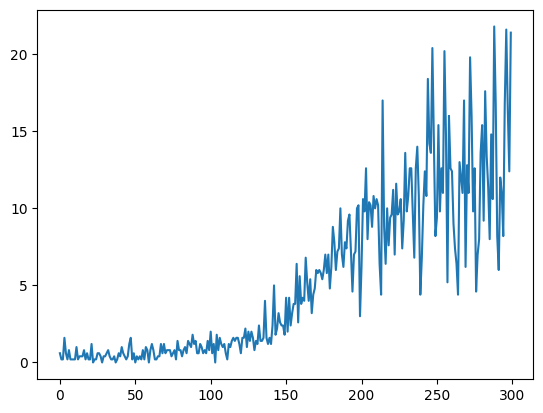

In [86]:
res_flattened = [np.mean(res[i:i+5]) for i in range(0, len(res), 5)]
plt.plot(res_flattened)

### DQN with CNN
Now that we've seen a DQN with MLPs to represent $Q$ work, let's try another representation that better fits the 2D format of input data: a Convolutional Neural Network.

In [29]:
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


class QConvNet(nn.Module):
    """Sequential CNN + minimal reshape logic for action-conditioned batches."""
    def __init__(self, in_channels: int = 7):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1),  # 10x10 -> 10x10
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                                      # 10x10 -> 5x5
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),          # 5x5 -> 5x5
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),         # 5x5 -> 5x5
            nn.ReLU(),
            nn.Flatten(start_dim=1),
            nn.Linear(128 * 5 * 5, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Accept both (A,C,H,W) and (B,A,C,H,W), like your previous QConvNet
        if x.ndim == 5:
            b, a, c, h, w = x.shape
            out = self.net(x.reshape(b * a, c, h, w))
            return out.view(b, a, 1)
        return self.net(x)


def phi_minatar_cnn(observation: torch.Tensor, actions: torch.Tensor) -> torch.Tensor:
    """Minimal action one-hot conditioning for CNN input.

    Returns shape:
    - (num_actions, 7, 10, 10) for single observation
    - (batch_size, num_actions, 7, 10, 10) for batched observations
    """
    actions_batched = actions.ndim == 2
    observation_batched = observation.ndim == 4
    batched = actions_batched or observation_batched

    if not observation_batched:
        observation = observation.unsqueeze(0)
    if not actions_batched:
        actions = actions.unsqueeze(0)

    if observation.shape[0] != actions.shape[0]:
        if observation.shape[0] == 1:
            observation = observation.expand(actions.shape[0], -1, -1, -1)
        elif actions.shape[0] == 1:
            actions = actions.expand(observation.shape[0], -1)
        else:
            raise ValueError(
                f"Batch sizes should match. Got obs={observation.shape[0]} and actions={actions.shape[0]}."
            )

    observation = observation.float().permute(0, 3, 1, 2).contiguous()  # (B,4,10,10)
    bsz, _, height, width = observation.shape

    action_onehot = F.one_hot(actions.long(), num_classes=3).float()  # (B,A,3)
    action_planes = action_onehot.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, -1, height, width)  # (B,A,3,H,W)
    obs_planes = observation.unsqueeze(1).expand(-1, actions.shape[1], -1, -1, -1)  # (B,A,4,H,W)

    phi = torch.cat([obs_planes, action_planes], dim=2)  # (B,A,7,H,W)

    if not batched:
        phi = phi.squeeze(0)

    return phi


mlp_reference = nn.Sequential(
    nn.Linear(72, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 256), nn.ReLU(),
    nn.Linear(256, 1),
)
cnn_reference = QConvNet(in_channels=7)

print(f"MLP params: {count_params(mlp_reference):,}")
print(f"CNN params: {count_params(cnn_reference):,}")

MLP params: 431,617
CNN params: 430,465


In [26]:
seed = 1
set_seed(seed)
env = gym.make("MinAtar/Breakout-v1")

cnn_agent = DQNAgent(
    action_dim=env.action_space.n,
    net=QConvNet(in_channels=7),
    phi=phi_minatar_cnn,
    lr=1e-3,
    lr_milestones=[500, 1000],
    gamma=0.99,
    batch_size=128,
    epsilon_decay_steps=15000,
)

env.close()

# Full run (uncomment when ready)
res_cnn = train_DQN(
    cnn_agent,
    "MinAtar/Breakout-v1",
    n_episodes=1500,
    seed=seed,
    eval_every=50,
    desc="DQN-CNN",
)

DQN-CNN:   0%|          | 0/1500 [00:00<?, ?it/s]

In [27]:
evaluate("MinAtar/Breakout-v1", lambda s: cnn_agent.act(s, explore=False), seed=seed)

15.8

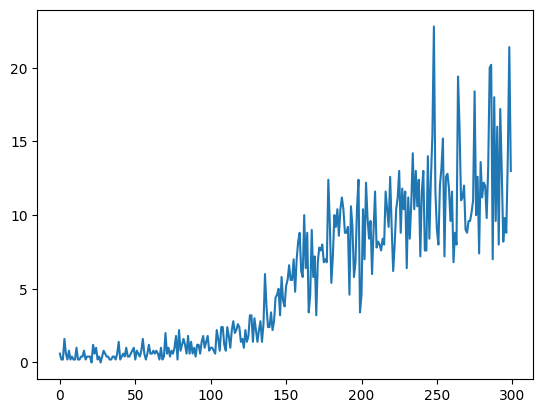

In [28]:
res_flattened = [np.mean(res_cnn[i:i+5]) for i in range(0, len(res_cnn), 5)]
plt.plot(res_flattened)

Now that we've proved the concept, let's train it longer.

In [34]:
seed = 1
set_seed(seed)
env = gym.make("MinAtar/Breakout-v1")

cnn_agent = DQNAgent(
    action_dim=env.action_space.n,
    net=QConvNet(in_channels=7),
    phi=phi_minatar_cnn,
    lr=1e-3,
    lr_milestones=[1000, 1500, 2000],
    gamma=0.99,
    batch_size=256,
    epsilon_decay_steps=15000,
)

env.close()

# Full run (uncomment when ready)
res_cnn = train_DQN(
    cnn_agent,
    "MinAtar/Breakout-v1",
    n_episodes=3000,
    seed=seed,
    eval_every=50,
    desc="DQN-CNN",
)

DQN-CNN:   0%|          | 0/3000 [00:00<?, ?it/s]

16.9


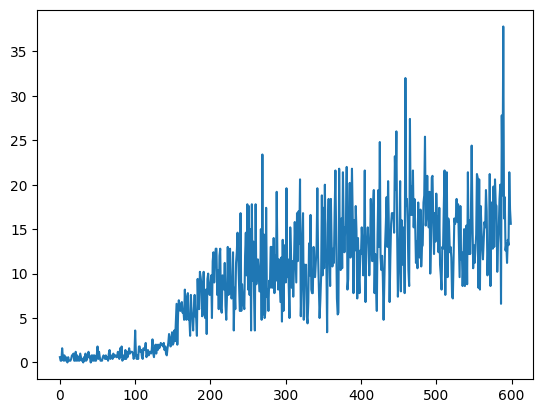

In [35]:
print(evaluate("MinAtar/Breakout-v1", lambda s: cnn_agent.act(s, explore=False), seed=seed))
res_flattened = [np.mean(res_cnn[i:i+5]) for i in range(0, len(res_cnn), 5)]
plt.plot(res_flattened, label="DQN-CNN 3000ep")

In [67]:
import json
torch.save(cnn_agent.q_net.state_dict(), "final_cnn.pth")
weights = torch.load("final_cnn.pth", weights_only=True)
loaded_net = QConvNet()
loaded_net.load_state_dict(weights)
final_agent = DQNAgent(
    3,
    loaded_net,
    phi_minatar_cnn,
)

print(evaluate("MinAtar/Breakout-v1", lambda s: final_agent.act(s, explore=False), seed=seed))

16.9


In [69]:
record_video("MinAtar/Breakout-v1", lambda s: final_agent.act(s, explore=False), seed=seed+1)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:334: UserWarning: WARN: No render fps was declared in the environment (env.metadata['render_fps'] is None or not defined), rendering may occur at inconsistent fps.
  logger.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:275: UserWarning: WARN: RGB-array rendering should return a numpy array with dtype uint8, got float64
  logger.warn(


---

## Part 4: Policy Interpretation [8 marks]

Analyze the behavior of your trained agents.

### Questions to Address

1. **Qualitative behavior**: Report a video of your trained agent playing. Describe its strategy in words. Does it behave similarly to the heuristic, or has it learned a different approach?

2. **State-action analysis**: For your best policy, visualize what actions it selects in different states.

3. **Failure cases**: Identify situations where the policy makes poor decisions. What do these cases have in common?

4. **Comparison across methods**: Do your classical and deep RL methods learn similar or different strategies? If not, why ?

### Answers

#### 1.

In [100]:
from matplotlib import animation
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore', category=UserWarning)


env = gym.make("MinAtar/Breakout-v1", render_mode="rgb_array")
state, _ = env.reset(seed=2)
frames = [env.render()]
done = False
step = 0

while not done:
    action = final_agent.act(state, explore=False)
    state, _, terminated, truncated, _ = env.step(action)
    frames.append(env.render())
    done = terminated or truncated
    step += 1
env.close()

def render_frames(frames):
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.axis("off")
    img = ax.imshow(frames[0])
    def update(f):
        img.set_data(f)
        return [img]
    anim = animation.FuncAnimation(fig, update, frames=frames, interval=150, blit=True)
    plt.close(fig)
    return HTML(anim.to_jshtml())

render_frames(frames)

In [102]:
render_frames(frames[40:100])

In [97]:
render_frames(frames[260:310])

Two strategies emerge depending on the configuration: 
- _2nd video_: the agent tends to be more physics-"aware" than the heuristic: when the ball goes to a wall, it tends to stay a few blocks away from it instead of following it. Additionaly, when the ball goes down it is able to infer its future position and move accordingly
- _3rd video_: when the ball is far at the top the agent tends to go and stay in the middle, while sometimes having an erratic behaviour following the ball's left-right motion.

#### 2.

In [254]:
import tqdm
states,actions = [],[]

env = gym.make("MinAtar/Breakout-v1", render_mode="rgb_array")

for seed in tqdm.tqdm(range(100)):
    state, _ = env.reset(seed=seed)
    done = False
    step = 0
    while not done:
        action = final_agent.act(state, explore=False)
        actions.append(action)
        states.append(state)
        state, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        step += 1
env.close()

states,actions = np.array(states), np.array(actions)

100%|██████████| 100/100 [00:15<00:00,  6.45it/s]


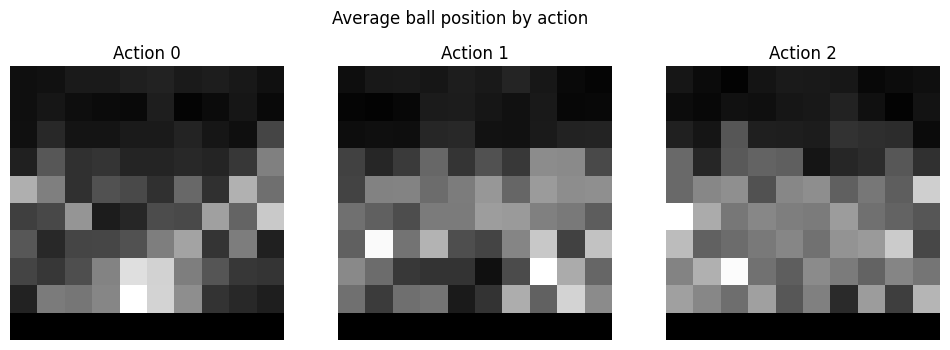

In [256]:
ball_by_action = {a: [] for a in range(3)}
x_by_action, y_by_action = np.zeros((3,10)), 3*np.zeros((3,10))
for s,a in zip(states, actions):
    head = s[:,:,1]
    tail = s[:,:,2]
    ball_by_action[a].append(head)
    x,y = np.where(head)[1].item(), np.where(head)[0].item()
    x_by_action[a,x] += 1
    y_by_action[a,y] += 1

mean_balls = {a: [] for a in range(3)}

for a,balls in ball_by_action.items():
    mean = np.mean(balls, axis=0)
    mean /= np.max(mean)
    mean_balls[a] = mean


plt.figure(figsize=(12,4))
for a in range(3):
    plt.subplot(1,3,a+1)
    plt.imshow(mean_balls[a], cmap="gray")
    plt.title(f"Action {a}")
    plt.axis("off")
plt.suptitle("Average ball position by action")
plt.show()

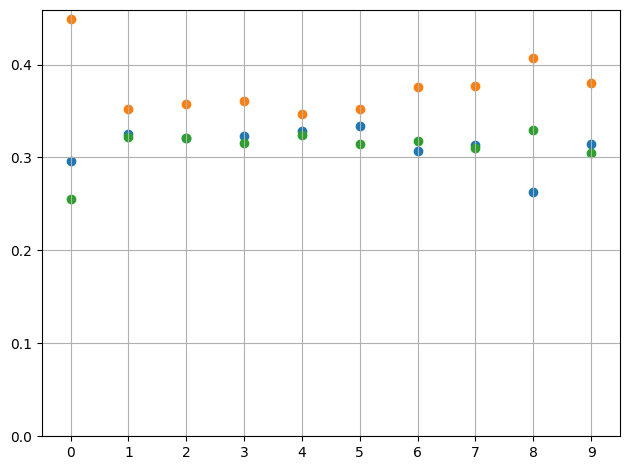

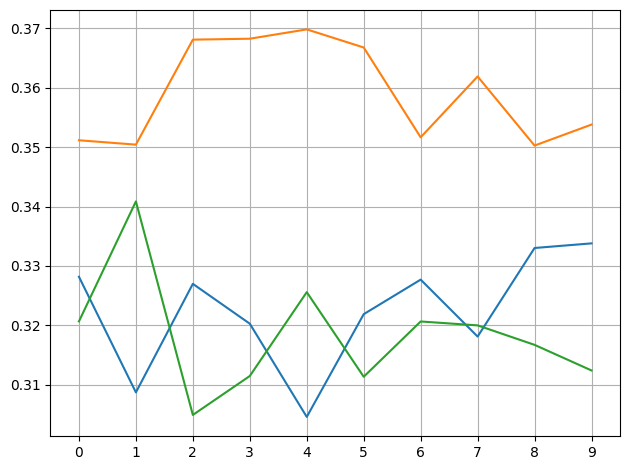

In [252]:
x_by_action /= x_by_action.sum(axis=0, keepdims=True)
y_by_action /= y_by_action.sum(axis=0, keepdims=True)

plt.scatter(np.arange(9,-1,-1), y_by_action[2])
plt.scatter(np.arange(9,-1,-1), y_by_action[0])
plt.scatter(np.arange(9,-1,-1), y_by_action[1])
plt.grid()
ax = plt.gca()
ax.set_ylim(bottom=0)
ax.set_xticks(np.arange(0, 11, 1))
ax.set_xlim(-0.5, 9.5)
plt.tight_layout()
plt.show()


plt.plot(np.arange(9,-1,-1), x_by_action[2])
plt.plot(np.arange(9,-1,-1), x_by_action[0])
plt.plot(np.arange(9,-1,-1), x_by_action[1])
plt.grid()
ax = plt.gca()
# ax.set_ylim(bottom=0)
ax.set_xticks(np.arange(0, 11, 1))
ax.set_xlim(-0.5, 9.5)
plt.tight_layout()
plt.show()

In [253]:
(len(states), len(actions))

(22228, 22128)

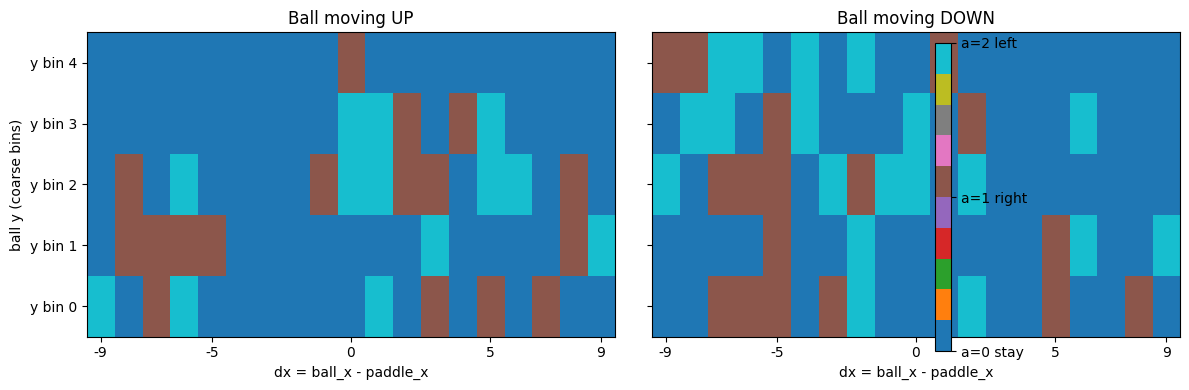

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n = min(len(states), len(actions))
S = states[:n]
A = actions[:n]

# Extract features
paddle_x = S[:, 9, :, 0].argmax(axis=1)  # paddle is on bottom row
head_flat = S[:, :, :, 1].reshape(n, -1).argmax(axis=1)
tail_flat = S[:, :, :, 2].reshape(n, -1).argmax(axis=1)

head_y, head_x = head_flat // 10, head_flat % 10
tail_y, tail_x = tail_flat // 10, tail_flat % 10

dx = head_x - paddle_x                      # [-9, 9]
vy = np.sign(head_y - tail_y).astype(int)  # -1 up, +1 down (0 rare)
# map vy to two bins: up=0, down=1
vy_bin = (vy > 0).astype(int)

# ball y bins (coarse)
y_bin = np.clip(head_y // 2, 0, 4)  # 5 bins: 0..4
dx_bin = np.clip(dx + 9, 0, 18)     # 19 bins: -9..9

# Count action frequencies: [vy(2), y(5), dx(19), action(3)]
counts = np.zeros((2, 5, 19, 3), dtype=np.float32)
for i in range(n):
    counts[vy_bin[i], y_bin[i], dx_bin[i], A[i]] += 1

probs = counts / np.maximum(counts.sum(axis=-1, keepdims=True), 1.0)
best_action = probs.argmax(axis=-1)  # [2,5,19]

# Plot decision maps (up/down)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
titles = ["Ball moving UP", "Ball moving DOWN"]

for k in range(2):
    im = axes[k].imshow(
        best_action[k], origin="lower", aspect="auto", cmap="tab10", vmin=0, vmax=2
    )
    axes[k].set_title(titles[k])
    axes[k].set_xlabel("dx = ball_x - paddle_x")
    axes[k].set_xticks([0, 4, 9, 14, 18])
    axes[k].set_xticklabels([-9, -5, 0, 5, 9])
    axes[k].set_yticks(range(5))
    axes[k].set_yticklabels([f"y bin {i}" for i in range(5)])

axes[0].set_ylabel("ball y (coarse bins)")
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), ticks=[0,1,2])
cbar.ax.set_yticklabels(["a=0 stay", "a=1 right", "a=2 left"])
plt.tight_layout()
plt.show()

In [ ]:
mean_frames = {}
for a in range(3):
    mean_frames[a] = np.mean(frames_by_action[a], axis=0)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for a in range(3):
    axes[a].imshow(mean_frames[a])
    axes[a].set_title(f"Action {a}")
    axes[a].axis("off")
plt.show()

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
  

---

## Part 5: Improving Performance [4 marks]

Investigate techniques to improve your agents' performance and training stability.

### Requirements

Choose **at least two** of the following directions:

- **Ablation study**: Remove or modify components of your algorithm and measure the impact.
- **Variance reduction**: Implement and compare techniques to reduce gradient variance.
- **Regularization**: Experiment with regularization techniques and analyze their effects.
- **Hyperparameter sensitivity**: Systematically vary hyperparameters and report their effects.
- **Exploration strategies**: Compare different exploration methods. [At least 2]

### Instructions for the report

For each investigation:
- State your hypothesis before running experiments
- Present results with appropriate visualizations
- Discuss whether results matched your expectations and explain any surprises
- Discuss the limitations and their probable solutions of your proposed approach.

## Ablation study

### d

## Exploration strategies

---

## Part 6: Generalization to Other Environments [5 marks]

Test whether your methods transfer to other MinAtar games: Asterix, Freeway, Seaquest, and Space Invaders.

### Questions to Address

1. **Direct transfer**: Apply your best Breakout agent (without retraining) to another game. Does it perform better than random? Why or why not?

2. **Retraining**: Train your deep RL method on at least one other MinAtar game. Does it achieve similar performance relative to the random baseline? If performance differs, explain why.

3. **Architecture/hyperparameter transfer**: Can you use the same configuration across games, or do different games require different configurations?

4. **Game difficulty**: Which games are easier or harder to learn? Relate this to environment properties.


---

## Summary

Conclude your notebook with a brief summary of:

- Your main findings across all parts
- What worked well and what did not
- What you would try next if you had more time

Make one paragraph answering these three points for each part of the assignment.